# Week 2 Live Session: How good is our model, and what about yes/no questions?

This notebook is for our call today. Mostly just run each cell in order (Shift + Enter) and we'll talk through what shows up.


## Part 1: How do we know if last week's line was any good?

Last week we found a line that fits the current/voltage data. But we never actually asked: **how good is that line?** Let's load the same data and the same line, and this time measure it.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix

df = pd.read_csv("data/ohms_law_readings.csv")
X = df[["current_mA"]]
y = df["voltage_V"]

model = LinearRegression()
model.fit(X, y)
predictions = model.predict(X)

print("slope:", model.coef_[0])
print("intercept:", model.intercept_)

slope: 0.10044277577717714
intercept: -0.02300506183683071


### Errors: the gap between what we predicted and what actually happened

For every point, we have an actual voltage and a predicted voltage. The difference between them is called the **error** (sometimes called the "residual"). Let's look at a few.


In [2]:
errors = y - predictions
comparison = pd.DataFrame({
    "current_mA": df["current_mA"],
    "actual_voltage": y,
    "predicted_voltage": predictions,
    "error": errors
})
comparison.head(10)

,current_mA,actual_voltage,predicted_voltage,error
0,5.93,0.576,0.572621,0.003379
1,7.09,0.681,0.689134,-0.008134
2,7.61,0.562,0.741364,-0.179364
3,7.93,0.915,0.773506,0.141494
4,9.40,0.843,0.921157,-0.078157
5,11.28,1.220,1.109989,0.110011
6,12.02,0.908,1.184317,-0.276317
7,12.02,1.233,1.184317,0.048683
8,12.67,1.088,1.249605,-0.161605
9,13.18,1.249,1.300831,-0.051831


Some errors are positive, some are negative. If we just add them all up, they'd partly cancel out and hide how wrong we really are. That's exactly why last week's formula squared every error before adding them up. Let's do that again here, but now let's actually total it up and give it a name.


In [3]:
squared_errors = errors ** 2
sse = squared_errors.sum()
mse = squared_errors.mean()
rmse = np.sqrt(mse)

print("Sum of squared errors (SSE):", sse)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Sum of squared errors (SSE): 0.6969208331208419
Mean Squared Error (MSE): 0.017423020828021045
Root Mean Squared Error (RMSE): 0.13199629096312154


**This is a real evaluation metric.** RMSE is in the same unit as voltage, so we can say it out loud like this: "on average, our line's predictions are off by about this many volts." Lower RMSE means a better-fitting line.

sklearn has this same calculation built in as one line, so we don't have to do it by hand every time:


In [4]:
mse_sklearn = mean_squared_error(y, predictions)
print("MSE from sklearn:", mse_sklearn)
print("Matches our manual calculation:", np.isclose(mse, mse_sklearn))

MSE from sklearn: 0.017423020828021045
Matches our manual calculation: True


---
## Part 2: A different kind of question

Here's a scenario. Imagine this same component has a safety rule: if the current running through it goes too high, it overheats and becomes unsafe. We want a model that answers: **"is this current level unsafe, yes or no?"**

Before we go further: think back to Week 1. Is "yes or no" a classification question or a regression question?

(Take a guess out loud before running the next cell.)


Right, that's classification. So the question becomes: can we still use linear regression for this?

Let's actually try it and see what happens.


In [5]:
df2 = pd.read_csv("data/session_current_safety.csv")
df2.head()

,current_mA,unsafe
0,6.24,0
1,8.30,0
2,8.60,0
3,8.82,0
4,11.66,0


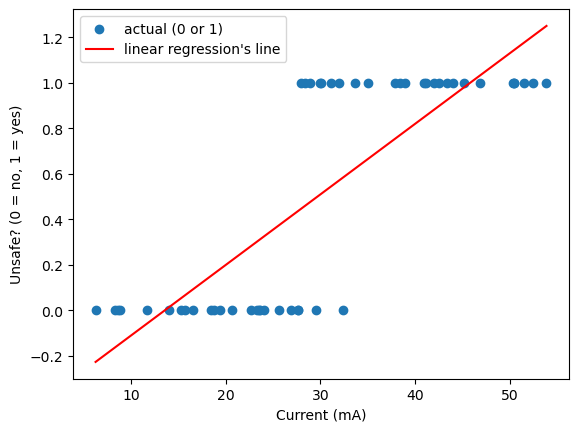

In [6]:
# df2["unsafe"] is 1 if the current was unsafe, 0 if it was safe.
# Let's try fitting an ordinary linear regression to predict it, just like we did for voltage.
X2 = df2[["current_mA"]]
y2 = df2["unsafe"]

linear_attempt = LinearRegression()
linear_attempt.fit(X2, y2)

plt.scatter(df2["current_mA"], df2["unsafe"], label="actual (0 or 1)")
plt.plot(df2["current_mA"], linear_attempt.predict(X2), color="red", label="linear regression's line")
plt.xlabel("Current (mA)")
plt.ylabel("Unsafe? (0 = no, 1 = yes)")
plt.legend()
plt.show()

**Here's the problem.** Look at the red line at the far left and far right of the plot. Linear regression happily predicts numbers like -0.2 or 1.3. But our answer can only ever be 0 or 1, "safe" or "unsafe." A prediction of -0.2 or 1.3 doesn't mean anything here. Linear regression doesn't know it's only allowed to output 0 or 1. That's its limitation for this kind of question.

## Logistic Regression: built for yes/no questions

**Logistic regression** fixes exactly this. Instead of drawing a straight line, it draws an S-shaped curve that is squeezed to always stay between 0 and 1. Instead of predicting the answer directly, it predicts **a probability** ("how likely is this to be unsafe?"), and then we pick a cutoff (usually 0.5) to turn that probability into a final yes/no answer.


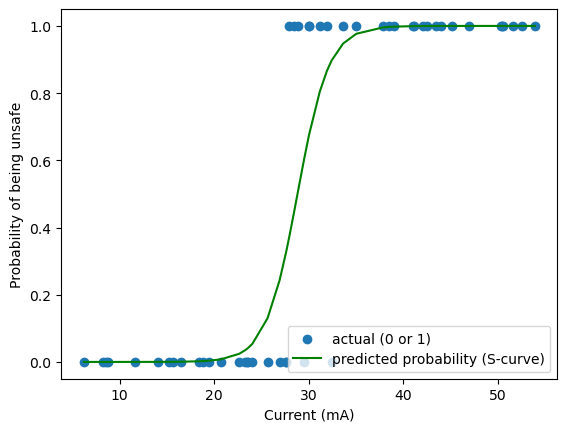

In [7]:
logreg = LogisticRegression()
logreg.fit(X2, y2)

# predict_proba gives us the probability of each class; we want the probability of "unsafe" (class 1)
probabilities = logreg.predict_proba(X2)[:, 1]

plt.scatter(df2["current_mA"], df2["unsafe"], label="actual (0 or 1)")
sort_idx = df2["current_mA"].argsort()
plt.plot(df2["current_mA"].values[sort_idx], probabilities[sort_idx], color="green", label="predicted probability (S-curve)")
plt.xlabel("Current (mA)")
plt.ylabel("Probability of being unsafe")
plt.legend()
plt.show()

Now the curve stays between 0 and 1 the whole way, no matter how far left or right we go. That's the whole point of logistic regression: it's built specifically for questions with a yes/no (or category) answer.


### Evaluating a classification model

RMSE doesn't really make sense here anymore, since we're not predicting a continuous number. For classification, the simplest metric is **accuracy**: what percentage of predictions did we get exactly right?


In [8]:
predicted_class = logreg.predict(X2)
accuracy = accuracy_score(y2, predicted_class)
print("Accuracy:", accuracy)
print(f"That means we got {accuracy*100:.0f}% of the predictions exactly right.")

Accuracy: 0.92
That means we got 92% of the predictions exactly right.


Accuracy alone can hide details, though. A **confusion matrix** breaks it down further: of the times we predicted "unsafe," how many actually were? Of the times we predicted "safe," how many actually were? Let's look.


In [9]:
cm = confusion_matrix(y2, predicted_class)
cm_table = pd.DataFrame(cm,
    index=["Actual: Safe", "Actual: Unsafe"],
    columns=["Predicted: Safe", "Predicted: Unsafe"])
cm_table

,Predicted: Safe,Predicted: Unsafe
Actual: Safe,22,2
Actual: Unsafe,2,24


(We built this exact same table with plain Excel formulas in the spreadsheet for today. If it's easier to look at there, we can switch over.)


---
## Part 3: A few pandas basics that will help with homework

Quick recap of a few small, useful pandas moves. Nothing new conceptually, just useful tools.


In [10]:
# 1. Creating a new column based on a condition
# Example: label any reading above 40 mA as "high"
df2["level"] = np.where(df2["current_mA"] > 40, "high", "normal")
df2.head()

,current_mA,unsafe,level
0,6.24,0,normal
1,8.30,0,normal
2,8.60,0,normal
3,8.82,0,normal
4,11.66,0,normal


In [11]:
# 2. value_counts() -- quickly see how many rows fall into each category
df2["unsafe"].value_counts()

unsafe
1    26
0    24
Name: count, dtype: int64

In [12]:
# 3. Filtering rows based on a condition
# Example: only look at the rows that were actually unsafe
df2[df2["unsafe"] == 1].head()

,current_mA,unsafe,level
22,27.95,1,normal
23,28.39,1,normal
24,28.87,1,normal
26,29.99,1,normal
27,30.06,1,normal


---
## Recap

- We measured how good a regression line is using errors, squared errors, MSE, and RMSE.
- We asked a yes/no question, tried linear regression on it, and saw why it breaks (predictions outside 0 and 1).
- Logistic regression fixes this by predicting a probability with an S-shaped curve, always between 0 and 1.
- We evaluated a classification model with accuracy and a confusion matrix.
- We picked up a few small pandas tools: creating a column from a condition, value_counts(), and filtering.

Homework this week uses everything above, on a new dataset, with a new electrical engineering scenario. See `week-02-logistic-regression` for that.
